<span style="color: lightblue">

# ML - PROJEKT ZALICZENIOWY
### 1. Project overview

<span>

In [143]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
                            accuracy_score, 
                            classification_report, 
                            confusion_matrix
                            )
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from miscs import print_participant_data_meaning
from utils import (
    bmi_calculation,
    check_balance,
    check_column_names_and_missing_values,
    data_reader,
    find_duplicates,
    generate_correlation_matrix,
    nulls_aggregation_report,
    one_hot_encode_columns,
    pca_method,
    rename_columns_snake_case,
    unique_values,
    optuna_objective,
)




In [144]:
df = data_reader('kukuroo3/body-signal-of-smoking/smoking.csv')

<span style="color: purple">

#### Problem badawczy: Klasyfikacja osób palących/niepalących na podstawie parametrów zdrowotnych i cech

<span>

In [145]:
df.head(100)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,118,M,25,175,65,75.0,1.5,1.5,1.0,1.0,...,14.9,1.0,0.7,15.0,13.0,15.0,Y,0,Y,1
96,119,M,40,170,75,89.0,0.8,1.5,1.0,1.0,...,15.8,1.0,0.9,30.0,23.0,35.0,Y,0,N,1
97,120,M,30,175,75,85.1,1.5,1.5,1.0,1.0,...,14.9,1.0,1.1,14.0,16.0,16.0,Y,0,Y,1
98,121,M,35,160,60,80.3,1.0,1.2,1.0,1.0,...,15.9,1.0,0.9,21.0,27.0,39.0,Y,0,N,0


In [146]:
df.shape
print(f"Dataset zawiera {df.shape[0]} obserwacji i {df.shape[1]} kolumn - 26 cech i target '{df.columns[-1]}' - problem binarny, ktorym jest identyfikacja czy badany jest palaczem czy nie.")

Dataset zawiera 55692 obserwacji i 27 kolumn - 26 cech i target 'smoking' - problem binarny, ktorym jest identyfikacja czy badany jest palaczem czy nie.


In [147]:
print_participant_data_meaning()

Semantyczne znaczenie danych ze zbioru:

| Dana | Znaczenie |
| :---- | :-------- |
| ID | Unikalny identyfikator badanego |
| gender | Płeć badanego (określone wartości) |
| age | Wiek badanego w latach |
| height(cm) | Wzrost badanego w centymetrach |
| weight(kg) | Waga badanego w kilogramach |
| waist(cm) | Obwód talii badanego w centymetrach |
| eyesight(left) | Ostrość wzroku w lewym oku |
| eyesight(right) | Ostrość wzroku w prawym oku |
| hearing(left) | Poziom słuchu w lewym uchu (określone wartości) |
| hearing(right) | Poziom słuchu w prawym uchu (określone wartości) |
| systolic | Ciśnienie skurczowe krwi badanego |
| relaxation | Ciśnienie rozkurczowe krwi badanego |
| fasting blood sugar | Poziom glukozy na czczo we krwi badanego |
| Cholesterol | Całkowity poziom cholesterolu we krwi |
| triglyceride | Poziom trójglicerydów we krwi |
| HDL | Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol) |
| LDL | Poziom cholesterolu LDL we krwi (tzw. zły cholesterol) |
| hemog

Semantyczne znaczenie danych ze zbioru:

| Dana | Znaczenie |
| :---- | :-------- |
| ID | Unikalny identyfikator badanego |
| gender | Płeć badanego (określone wartości) |
| age | Wiek badanego w latach |
| height(cm) | Wzrost badanego w centymetrach |
| weight(kg) | Waga badanego w kilogramach |
| waist(cm) | Obwód talii badanego w centymetrach |
| eyesight(left) | Ostrość wzroku w lewym oku |
| eyesight(right) | Ostrość wzroku w prawym oku |
| hearing(left) | Poziom słuchu w lewym uchu (określone wartości) |
| hearing(right) | Poziom słuchu w prawym uchu (określone wartości) |
| systolic | Ciśnienie skurczowe krwi badanego |
| relaxation | Ciśnienie rozkurczowe krwi badanego |
| fasting blood sugar | Poziom glukozy na czczo we krwi badanego |
| Cholesterol | Całkowity poziom cholesterolu we krwi |
| triglyceride | Poziom trójglicerydów we krwi |
| HDL | Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol) |
| LDL | Poziom cholesterolu LDL we krwi (tzw. zły cholesterol) |
| hemoglobin | Poziom hemoglobiny we krwi badanego |
| Urine protein | Zawartość białka w moczu badanego |
| serum creatinine | Poziom kreatyniny w surowicy krwi (wskaźnik funkcji nerek) |
| AST | Poziom enzymu AST (wskaźnik funkcji wątroby) |
| ALT | Poziom enzymu ALT (wskaźnik funkcji wątroby) |
| Gtp | Poziom gamma-GTP (wskaźnik funkcji wątroby) |
| oral | Stan zdrowia jamy ustnej badanego (ogólna ocena) |
| dental caries | Informacja o występowaniu próchnicy |
| tartar | Informacja o obecności kamienia nazębnego |
| smoking | Informacja o statusie palenia badanego (określone wartości) |

<span style="color: lightblue">

### 2. EDA - Explanatory data analysis
<span>

In [148]:
df_nulls = check_column_names_and_missing_values(df)

In [149]:
print("Lista kolumn w zbiorze danych:")
df_nulls['col_name']

Lista kolumn w zbiorze danych:


0                      ID
1                  gender
2                     age
3              height(cm)
4              weight(kg)
5               waist(cm)
6          eyesight(left)
7         eyesight(right)
8           hearing(left)
9          hearing(right)
10               systolic
11             relaxation
12    fasting blood sugar
13            Cholesterol
14           triglyceride
15                    HDL
16                    LDL
17             hemoglobin
18          Urine protein
19       serum creatinine
20                    AST
21                    ALT
22                    Gtp
23                   oral
24          dental caries
25                 tartar
26                smoking
Name: col_name, dtype: object

In [150]:
print("Braki danych per kolumna:")
df_nulls


Braki danych per kolumna:


,col_name,num_nulls
0,ID,0
1,gender,0
2,age,0
3,height(cm),0
4,weight(kg),0
5,waist(cm),0
6,eyesight(left),0
7,eyesight(right),0
8,hearing(left),0
9,hearing(right),0


In [151]:
print(nulls_aggregation_report(df))

W zbiorze danych nie ma braków danych.


In [152]:
df = rename_columns_snake_case(df)
df.columns

Index(['id', 'gender', 'age', 'height_cm', 'weight_kg', 'waist_cm',
       'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right',
       'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol',
       'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein',
       'serum_creatinine', 'ast', 'alt', 'gtp', 'oral', 'dental_caries',
       'tartar', 'smoking'],
      dtype='object')

In [153]:
print(f'Unikalne wartosci w kazdej kolumnie:\n')
df.nunique().sort_values()


Unikalne wartosci w kazdej kolumnie:



oral                       1
gender                     2
hearing_right              2
hearing_left               2
dental_caries              2
tartar                     2
smoking                    2
urine_protein              6
height_cm                 13
age                       14
eyesight_right            17
eyesight_left             19
weight_kg                 22
serum_creatinine          38
relaxation                95
hdl                      126
systolic                 130
hemoglobin               145
ast                      219
alt                      245
fasting_blood_sugar      276
cholesterol              286
ldl                      289
triglyceride             390
gtp                      488
waist_cm                 566
id                     55692
dtype: int64

In [154]:
unique_values(df, 600)

gender: object, ['F', 'M']

oral: object, ['Y']

tartar: object, ['N', 'Y']



In [155]:
df = df.drop(columns=['oral'])

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height_cm            55692 non-null  int64  
 4   weight_kg            55692 non-null  int64  
 5   waist_cm             55692 non-null  float64
 6   eyesight_left        55692 non-null  float64
 7   eyesight_right       55692 non-null  float64
 8   hearing_left         55692 non-null  float64
 9   hearing_right        55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting_blood_sugar  55692 non-null  float64
 13  cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  hdl                  55692 non-null 

In [157]:
df = one_hot_encode_columns(df, ['gender', 'tartar'])
df.head()

,id,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,...,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,dental_caries,smoking,gender_M,tartar_Y
0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,0,0,False,True
1,1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,0,0,False,True
2,2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,0,1,True,False
3,3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,0,0,True,True
4,4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,0,0,False,False


In [158]:
df.describe().round(2)

,id,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,...,hdl,ldl,hemoglobin,urine_protein,serum_creatinine,ast,alt,gtp,dental_caries,smoking
count,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,...,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00,55692.00
mean,27845.50,44.18,164.65,65.86,82.05,1.01,1.01,1.03,1.03,121.49,...,57.29,114.96,14.62,1.09,0.89,26.18,27.04,39.95,0.21,0.37
std,16077.04,12.07,9.19,12.82,9.27,0.49,0.49,0.16,0.16,13.68,...,14.74,40.93,1.56,0.40,0.22,19.36,30.95,50.29,0.41,0.48
min,0.00,20.00,130.00,30.00,51.00,0.10,0.10,1.00,1.00,71.00,...,4.00,1.00,4.90,1.00,0.10,6.00,1.00,1.00,0.00,0.00
25%,13922.75,40.00,160.00,55.00,76.00,0.80,0.80,1.00,1.00,112.00,...,47.00,92.00,13.60,1.00,0.80,19.00,15.00,17.00,0.00,0.00
50%,27845.50,40.00,165.00,65.00,82.00,1.00,1.00,1.00,1.00,120.00,...,55.00,113.00,14.80,1.00,0.90,23.00,21.00,25.00,0.00,0.00
75%,41768.25,55.00,170.00,75.00,88.00,1.20,1.20,1.00,1.00,130.00,...,66.00,136.00,15.80,1.00,1.00,28.00,31.00,43.00,0.00,1.00
max,55691.00,85.00,190.00,135.00,129.00,9.90,9.90,2.00,2.00,240.00,...,618.00,1860.00,21.10,6.00,11.60,1311.00,2914.00,999.00,1.00,1.00


In [159]:
print(find_duplicates(df))

('Nie znaleziono zduplikowanych obserwacji.', Empty DataFrame
Columns: [id, age, height_cm, weight_kg, waist_cm, eyesight_left, eyesight_right, hearing_left, hearing_right, systolic, relaxation, fasting_blood_sugar, cholesterol, triglyceride, hdl, ldl, hemoglobin, urine_protein, serum_creatinine, ast, alt, gtp, dental_caries, smoking, gender_M, tartar_Y]
Index: []

[0 rows x 26 columns])


In [160]:
df = df.drop(columns=['id'])

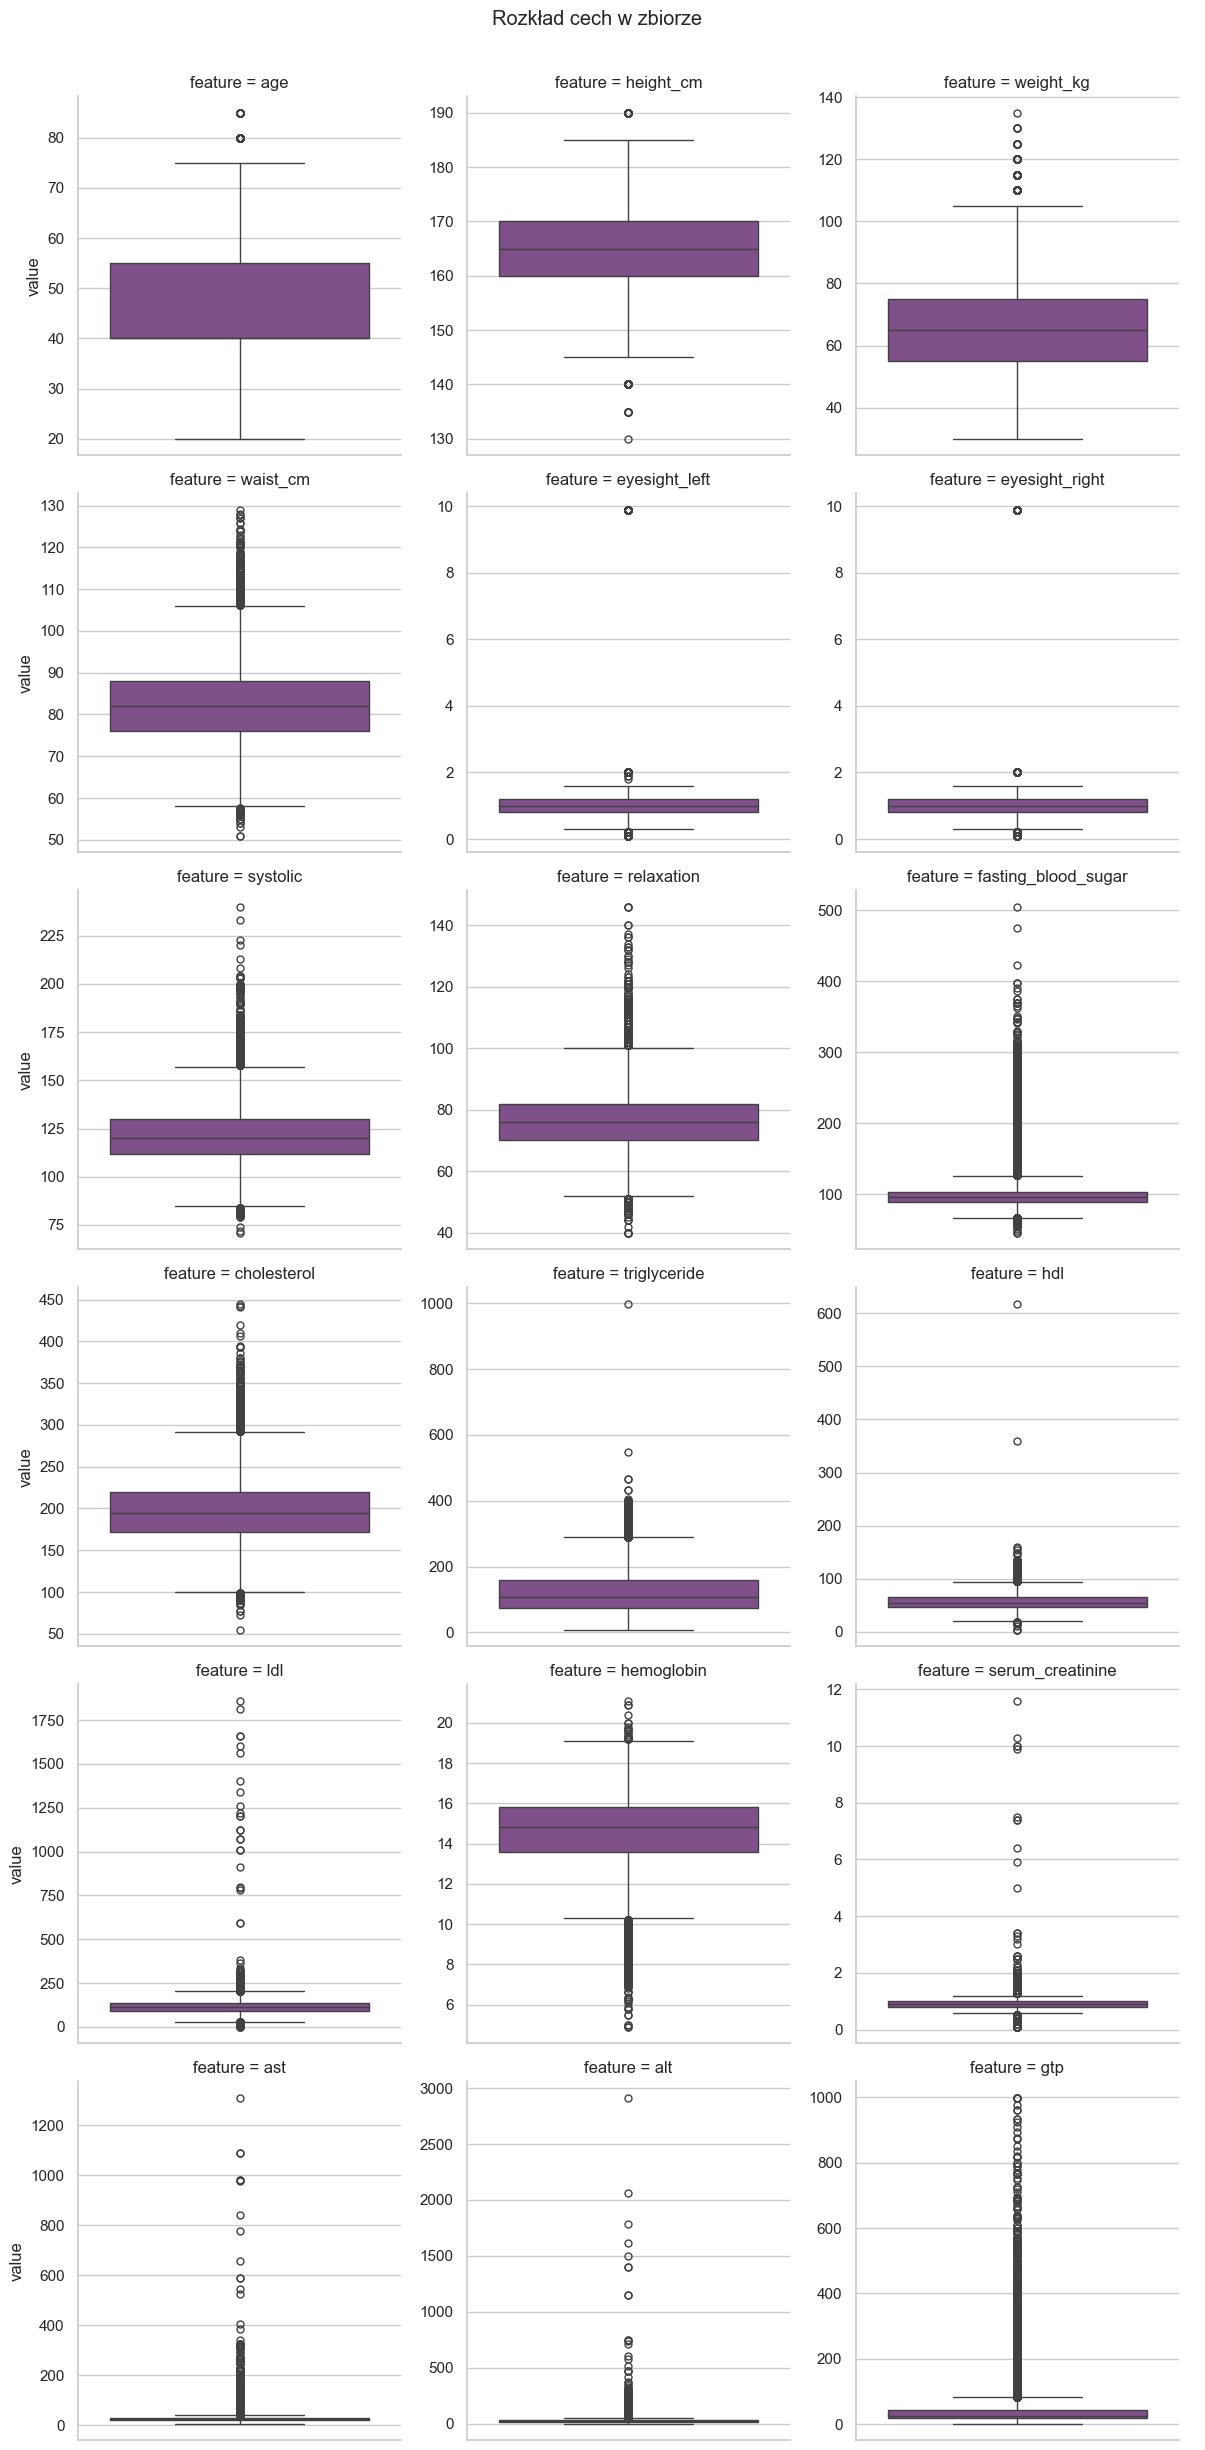

In [161]:
cols = ['age', 'height_cm', 'weight_kg', 'waist_cm', 'eyesight_left', 'eyesight_right', 'systolic', 'relaxation', 'fasting_blood_sugar', 'cholesterol', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'serum_creatinine', 'ast', 'alt', 'gtp']
df_long = df.melt(id_vars='smoking', value_vars=cols,
                  var_name='feature', value_name='value')
g = sns.catplot(
    data=df_long,
    y='value',
    kind='box',
    col='feature',
    col_wrap=3,   
    height=4,
    sharey=False
)
g.fig.suptitle('Rozkład cech w zbiorze', y=1.02)
plt.show()


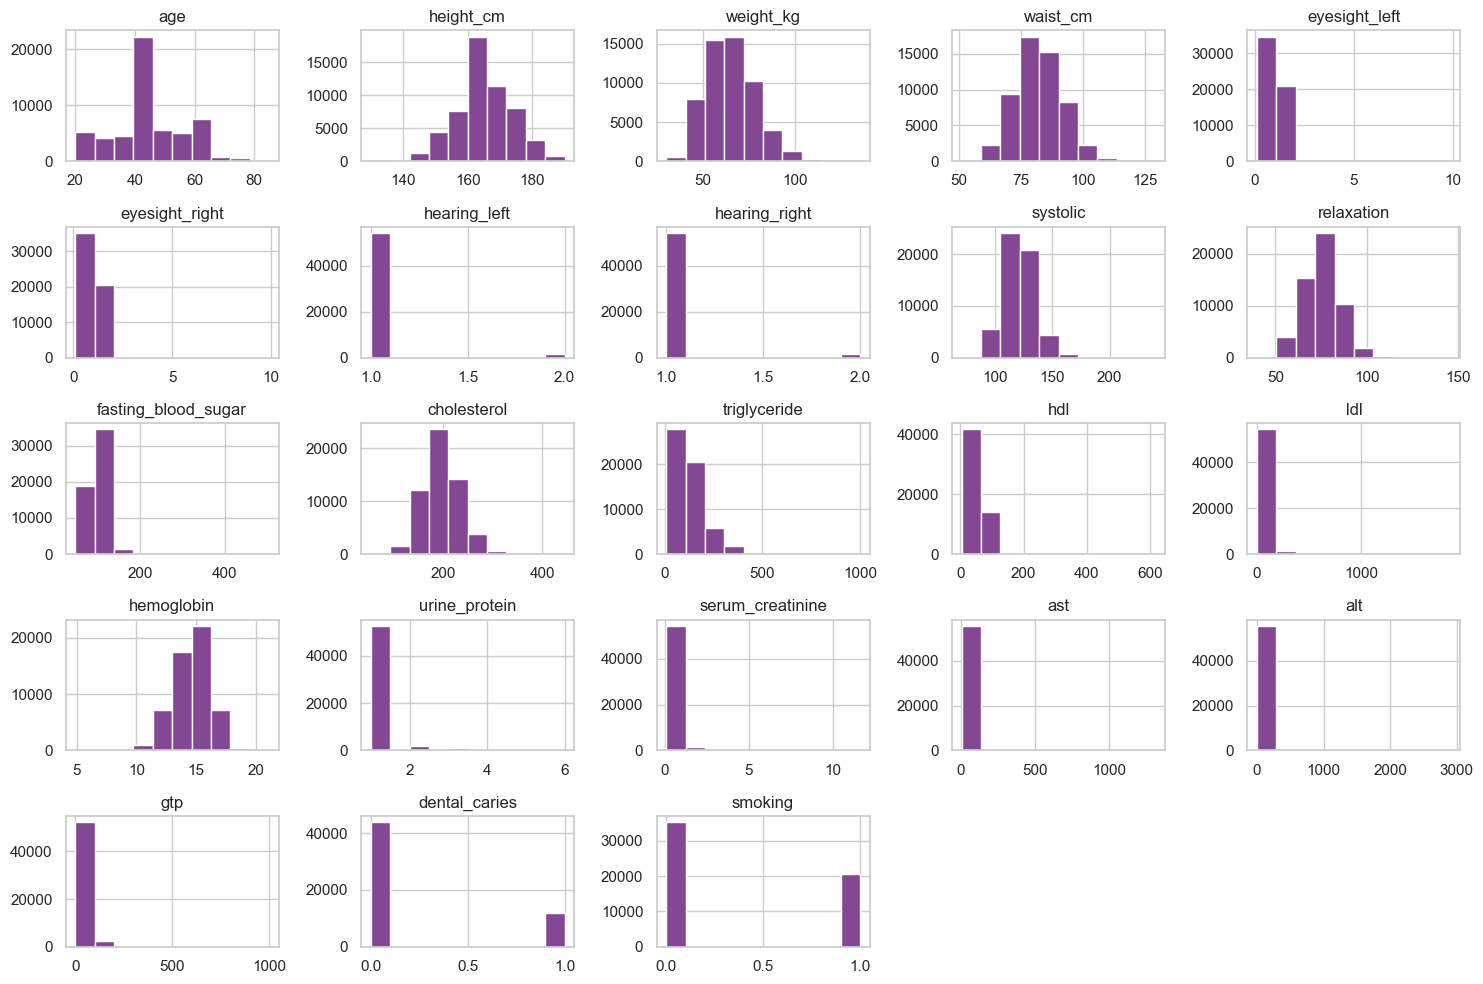

In [162]:
df.hist(figsize=(15, 10), bins=10)
plt.tight_layout()
plt.show()

In [163]:
pearson_vars = ['age', 'waist_cm', 'height_cm', 'weight_kg', 'systolic', 'relaxation', 'hemoglobin']
spearman_vars = ['fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl', 'ast', 'alt', 'gtp', 'serum_creatinine']
kendall_vars = ['hearing_left', 'hearing_right', 'urine_protein', 'dental_caries', 'tartar_Y', 'gender_M']

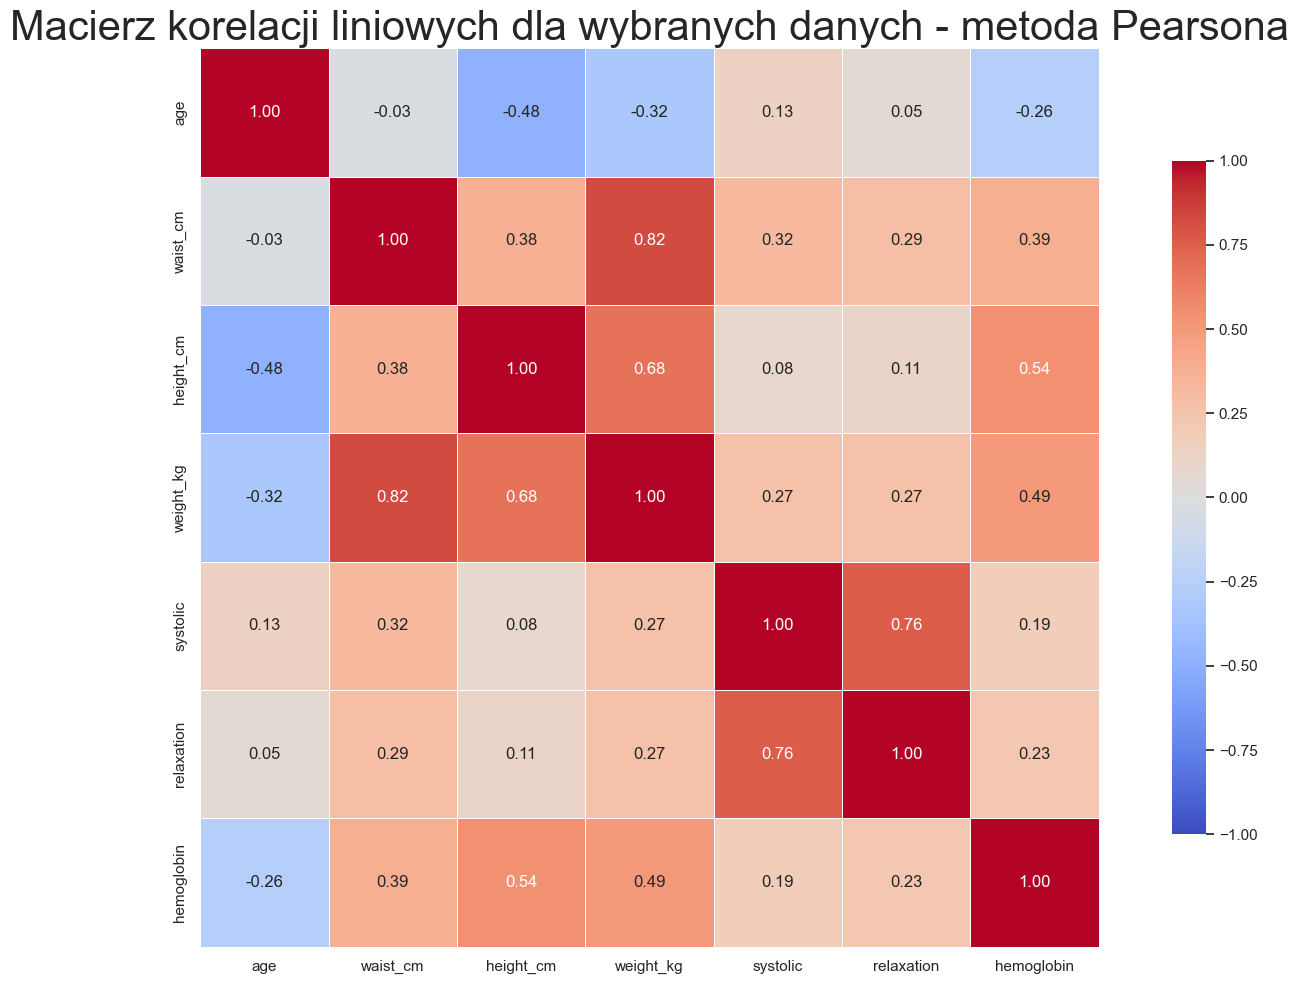

In [164]:
generate_correlation_matrix(df[pearson_vars], method='pearson', title='Macierz korelacji liniowych dla wybranych danych - metoda Pearsona')

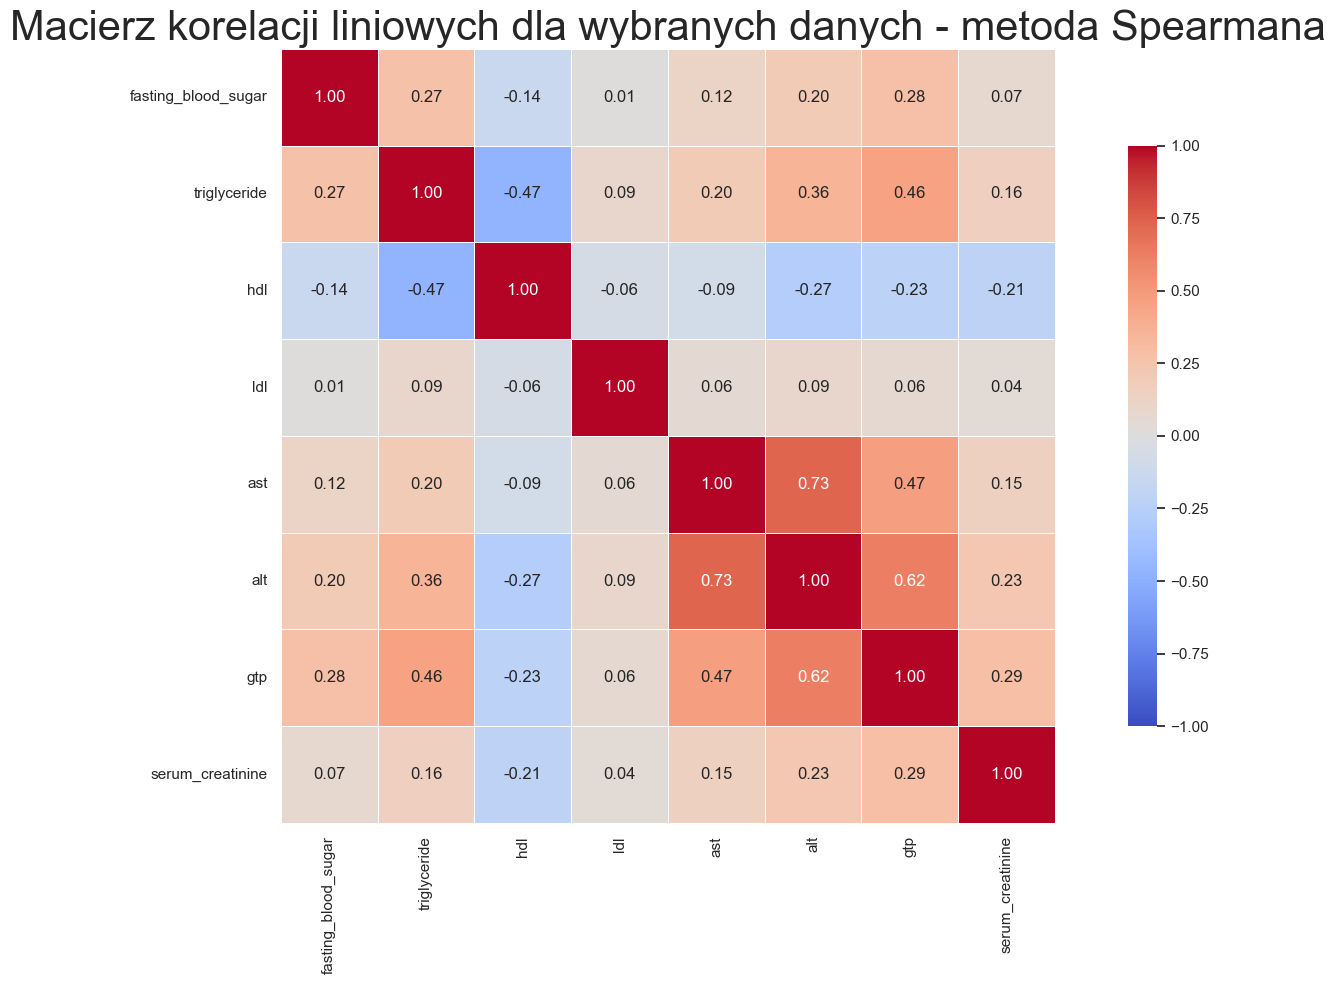

In [165]:
generate_correlation_matrix(df[spearman_vars], method='spearman', title='Macierz korelacji liniowych dla wybranych danych - metoda Spearmana')

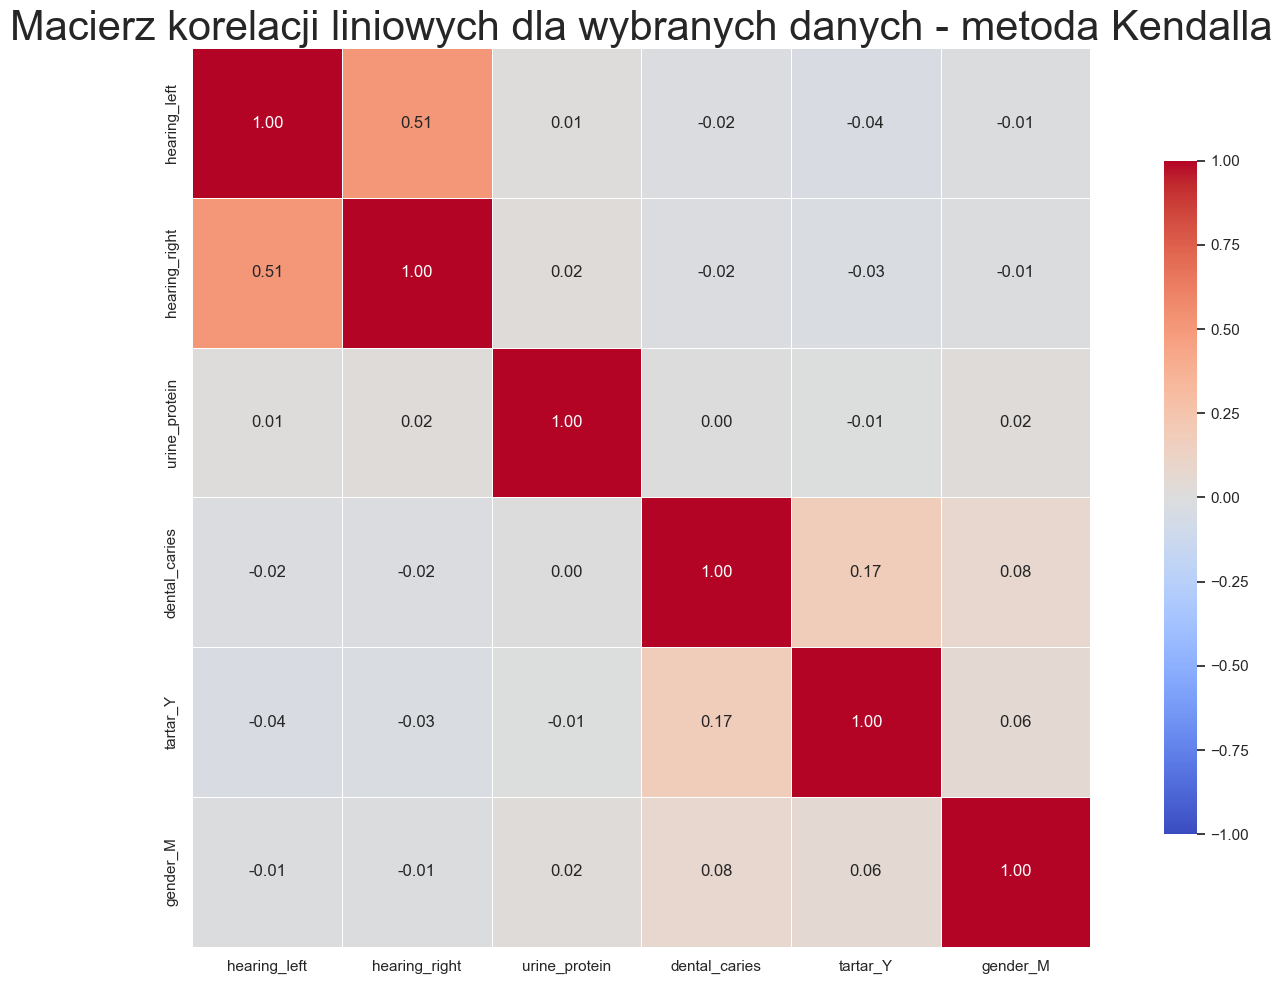

In [166]:
generate_correlation_matrix(df[kendall_vars], method='kendall', title='Macierz korelacji liniowych dla wybranych danych - metoda Kendalla')

In [167]:
df["systolic_relaxation_multiplication"] = (df["systolic"] * df["relaxation"]) ** 2
cols_to_drop = ['relaxation', 'systolic']
df = df.drop(cols_to_drop, axis=1)

In [168]:
df["BMI"] = df.apply(lambda x: bmi_calculation(x["weight_kg"], x['height_cm']), axis=1)
cols_to_drop = ['waist_cm', 'weight_kg', 'height_cm']
df = df.drop(cols_to_drop, axis=1)



In [169]:
df = pca_method(df, n_components=1, feature_names=['ast', 'alt'], new_feature_name='ast_alt_pca')
df.head()

,age,eyesight_left,eyesight_right,hearing_left,hearing_right,fasting_blood_sugar,cholesterol,triglyceride,hdl,ldl,...,urine_protein,serum_creatinine,gtp,dental_caries,smoking,gender_M,tartar_Y,systolic_relaxation_multiplication,BMI,ast_alt_pca
0,40,1.2,1.0,1.0,1.0,94.0,215.0,82.0,73.0,126.0,...,1.0,0.7,27.0,0,0,False,True,69255684.0,25,-10.957648
1,40,0.8,0.6,1.0,1.0,130.0,192.0,115.0,42.0,127.0,...,1.0,0.6,18.0,0,0,False,True,69388900.0,23,-9.058527
2,55,0.8,0.8,1.0,1.0,89.0,242.0,182.0,55.0,151.0,...,1.0,1.0,22.0,0,1,True,False,140849424.0,21,-12.173620
3,40,1.5,1.5,1.0,1.0,96.0,322.0,254.0,45.0,226.0,...,1.0,1.0,18.0,0,0,True,True,36000000.0,26,-4.322137
4,40,1.0,1.0,1.0,1.0,80.0,184.0,74.0,62.0,107.0,...,1.0,0.6,22.0,0,0,False,False,78854400.0,25,-16.307730


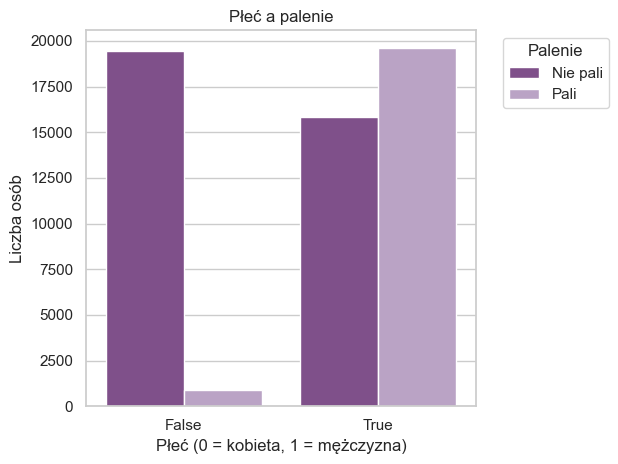

In [170]:
sns.set_style('whitegrid') 
sns.set_palette('PRGn') 
sns.set_context('notebook')
sns.countplot(x='gender_M', hue='smoking', data=df)
plt.title("Płeć a palenie")
plt.xlabel("Płeć (0 = kobieta, 1 = mężczyzna)")
plt.ylabel("Liczba osób")
plt.legend(
    title="Palenie",
    labels=["Nie pali", "Pali"],
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',         
)
plt.tight_layout()
plt.show()

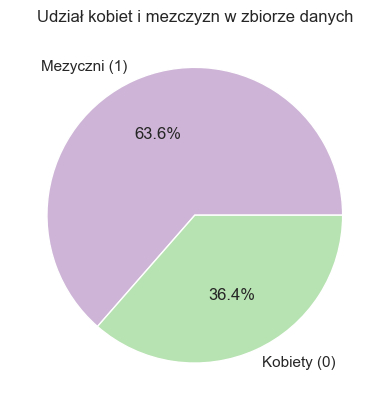

In [171]:
labels = [ 'Mezyczni (1)', 'Kobiety (0)']
colors = sns.color_palette("PRGn", n_colors=2)
df['gender_M'].value_counts(normalize=True).plot(
    kind='pie',
    autopct='%1.1f%%', 
    labels = labels,   
    colors=colors, 
    title='Udział kobiet i mezczyzn w zbiorze danych',
    ylabel='')
plt.show()

In [172]:
check_balance(df, 'gender_M')

'Lekka nierównowaga – akceptowalna.'

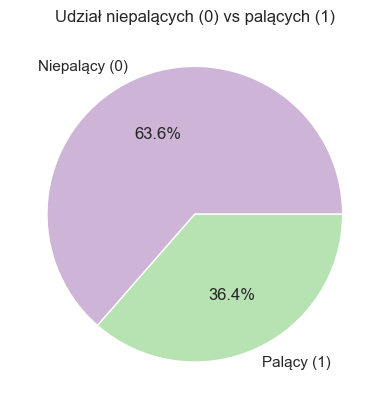

In [173]:
labels = ['Niepalący (0)', 'Palący (1)']
colors = sns.color_palette("PRGn", n_colors=2)
df['gender_M'].value_counts(normalize=False).plot(
    kind='pie',
    autopct='%1.1f%%', 
    labels=labels,     
    colors=colors, 
    title='Udział niepalących (0) vs palących (1)',
    ylabel=''                
)
plt.show()


In [174]:
target = df['smoking']

In [175]:
check_balance(df, 'smoking')

'Lekka nierównowaga – akceptowalna.'

<span style="color: lightblue">

### 3. Modelling
<span>

In [176]:
X = df.drop('smoking', axis=1)
y = df['smoking']

In [177]:
feature_names = X.columns.tolist()
target_names = y.unique().tolist() 

print("Feature names:", feature_names)
print("Target names:", target_names)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("\nDistribution of target variable:")
print(y.value_counts(normalize=True).round(2))

Feature names: ['age', 'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right', 'fasting_blood_sugar', 'cholesterol', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'gtp', 'dental_caries', 'gender_M', 'tartar_Y', 'systolic_relaxation_multiplication', 'BMI', 'ast_alt_pca']
Target names: [0, 1]
Number of samples: 55692
Number of features: 20

Distribution of target variable:
smoking
0    0.63
1    0.37
Name: proportion, dtype: float64


In [178]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_scaled = scaler.fit_transform(X_train)
X_ts_scaled = scaler.transform(X_test)



print("Number of training samples:", len(X_tr_scaled))
print("Number of test samples:", len(X_ts_scaled))


Number of training samples: 44553
Number of test samples: 11139


In [179]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_scaled, y_train)

accuracy = model.score(X_ts_scaled, y_test)
print("Model accuracy:", accuracy)

Model accuracy: 0.739653469790825


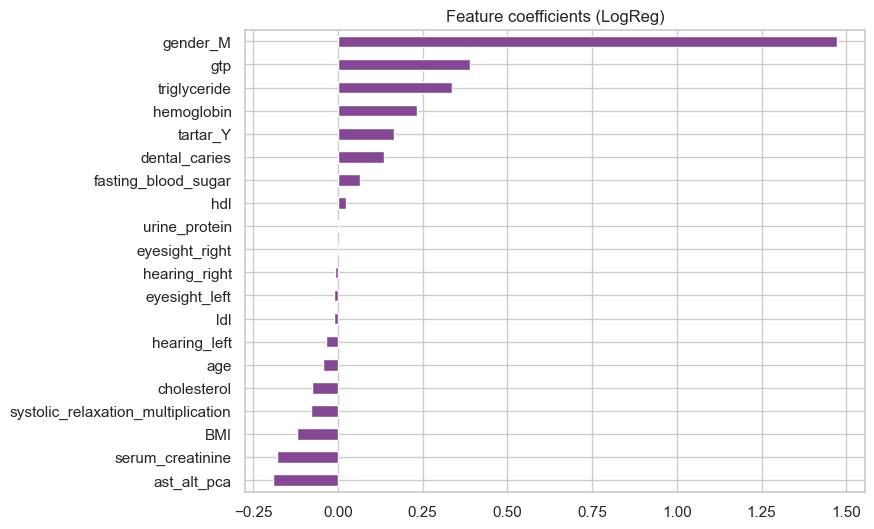

In [180]:
coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
coef.plot(kind='barh', figsize=(8,6))
plt.title("Feature coefficients (LogReg)")
plt.show()


Sample predictions:
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 1
Predicted: 1 | Actual: 0
Predicted: 1 | Actual: 0
Predicted: 1 | Actual: 0
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      7027
           1       0.64      0.69      0.66      4112

    accuracy                           0.74     11139
   macro avg       0.72      0.73      0.72     11139
weighted avg       0.74      0.74      0.74     11139

Confusion Matrix:


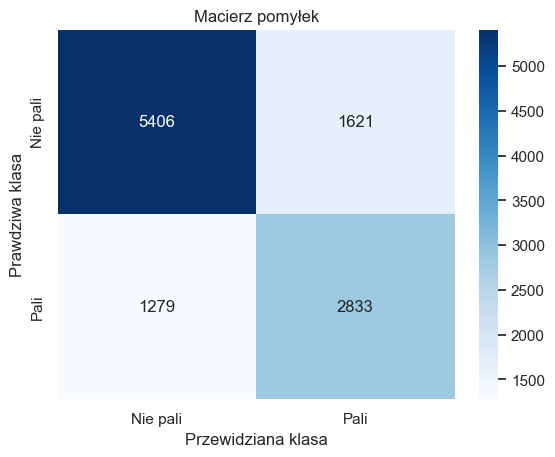

In [181]:

predictions = model.predict(X_ts_scaled)
model.coef_

print("Sample predictions:")
for i in range(5):
    print("Predicted:", predictions[i], "| Actual:", y_test.iloc[i])


print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")


conf_mat = confusion_matrix(y_test, predictions)

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Nie pali', 'Pali'],
    yticklabels=['Nie pali', 'Pali']
)
plt.title('Macierz pomyłek')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Prawdziwa klasa')
plt.show()



In [182]:
seed = 7
test_size = 0.33
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
model = XGBClassifier()

model.fit(X_train, y_train)

print(model)

y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Accuracy: 77.53%


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     11648
           1       0.69      0.71      0.70      6731

    accuracy                           0.78     18379
   macro avg       0.76      0.76      0.76     18379
weighted avg       0.78      0.78      0.78     18379

Confusion Matrix:
[[9483 2165]
 [1965 4766]]


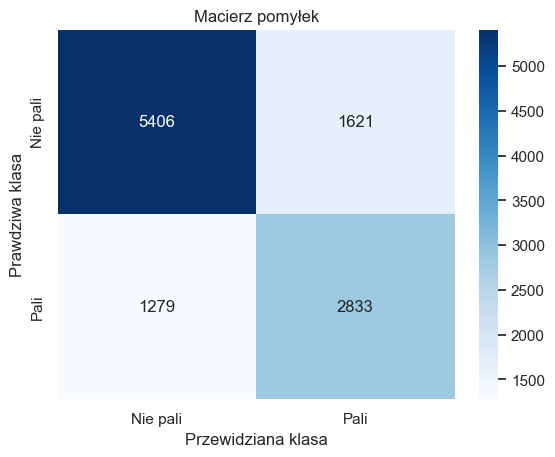

In [183]:
print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")

print(confusion_matrix(y_test, predictions))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Nie pali', 'Pali'],
    yticklabels=['Nie pali', 'Pali']
)
plt.title('Macierz pomyłek')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Prawdziwa klasa')
plt.show()

In [184]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

ypred = rf.predict(X_test)

print("Score the X-train with Y-train is : ", rf.score(X_train,y_train))
print("Score the X-test  with Y-test  is : ", rf.score(X_test,y_test))
print("Accuracy Score :",accuracy_score(y_test,ypred)*100)

Score the X-train with Y-train is :  0.9999195990673492
Score the X-test  with Y-test  is :  0.8174547037379618
Accuracy Score : 81.74547037379618


<span style="color: lightblue">

### 4. Optimalisation
<span>

In [185]:

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test), n_trials=40, show_progress_bar=True)

trial = study.best_trial

print('Accuracy: {}'.format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

[I 2025-11-19 00:54:45,578] A new study created in memory with name: no-name-e7ae1550-cbf4-4069-b0dd-006e15d61033
Best trial: 0. Best value: 0.767615:   2%|▎         | 1/40 [00:01<00:52,  1.34s/it]

[I 2025-11-19 00:54:46,926] Trial 0 finished with value: 0.7676152130148539 and parameters: {'n_estimators': 762, 'learning_rate': 0.01942948990383632, 'max_depth': 8, 'subsample': 0.057620187904400565, 'colsample_bytree': 0.5418793229049971, 'min_child_weight': 4}. Best is trial 0 with value: 0.7676152130148539.


Best trial: 1. Best value: 0.769955:   5%|▌         | 2/40 [00:03<01:19,  2.09s/it]

[I 2025-11-19 00:54:49,530] Trial 1 finished with value: 0.7699548397627727 and parameters: {'n_estimators': 559, 'learning_rate': 0.009862021146999385, 'max_depth': 8, 'subsample': 0.4845042449823449, 'colsample_bytree': 0.6682366589275878, 'min_child_weight': 11}. Best is trial 1 with value: 0.7699548397627727.


Best trial: 1. Best value: 0.769955:   8%|▊         | 3/40 [00:05<01:14,  2.01s/it]

...

[I 2025-11-19 19:53:34,942] Trial 37 finished with value: 0.7784971978888949 and parameters: {'n_estimators': 496, 'learning_rate': 0.06499674452504337, 'max_depth': 9, 'subsample': 0.8251865605167837, 'colsample_bytree': 0.23866030704871016, 'min_child_weight': 20}. Best is trial 27 with value: 0.7991185592252027.


Best trial: 27. Best value: 0.799119:  98%|█████████▊| 39/40 [18:58:53<00:26, 26.68s/it]

[I 2025-11-19 19:53:38,753] Trial 38 finished with value: 0.7909026606453017 and parameters: {'n_estimators': 744, 'learning_rate': 0.03178307876518607, 'max_depth': 10, 'subsample': 0.8813267847693959, 'colsample_bytree': 0.6573253464373588, 'min_child_weight': 16}. Best is trial 27 with value: 0.7991185592252027.


Best trial: 27. Best value: 0.799119: 100%|██████████| 40/40 [18:58:55<00:00, 1708.39s/it]

[I 2025-11-19 19:53:41,361] Trial 39 finished with value: 0.7949834049730671 and parameters: {'n_estimators': 668, 'learning_rate': 0.07058963947065643, 'max_depth': 10, 'subsample': 0.7714861675839605, 'colsample_bytree': 0.49620001389145596, 'min_child_weight': 18}. Best is trial 27 with value: 0.7991185592252027.
Accuracy: 0.7991185592252027
Best hyperparameters: {'n_estimators': 641, 'learning_rate': 0.09789652132128392, 'max_depth': 10, 'subsample': 0.6977503049346663, 'colsample_bytree': 0.5929228727592573, 'min_child_weight': 20}


<span style="color: lightblue">

### 5. Results interpretation
<span>

In [186]:
X_train['gender_M'] = X_train['gender_M'].astype(int)
X_train['tartar_Y'] = X_train['tartar_Y'].astype(int)

In [187]:
X_train.dtypes

age                                     int64
eyesight_left                         float64
eyesight_right                        float64
hearing_left                          float64
hearing_right                         float64
fasting_blood_sugar                   float64
cholesterol                           float64
triglyceride                          float64
hdl                                   float64
ldl                                   float64
hemoglobin                            float64
urine_protein                         float64
serum_creatinine                      float64
gtp                                   float64
dental_caries                           int64
gender_M                                int64
tartar_Y                                int64
systolic_relaxation_multiplication    float64
BMI                                     int64
ast_alt_pca                           float64
dtype: object

In [188]:
feature_names = X_train.columns.tolist()
feature_names

['age',
 'eyesight_left',
 'eyesight_right',
 'hearing_left',
 'hearing_right',
 'fasting_blood_sugar',
 'cholesterol',
 'triglyceride',
 'hdl',
 'ldl',
 'hemoglobin',
 'urine_protein',
 'serum_creatinine',
 'gtp',
 'dental_caries',
 'gender_M',
 'tartar_Y',
 'systolic_relaxation_multiplication',
 'BMI',
 'ast_alt_pca']

 99%|===================| 18227/18379 [32:05<00:16]        

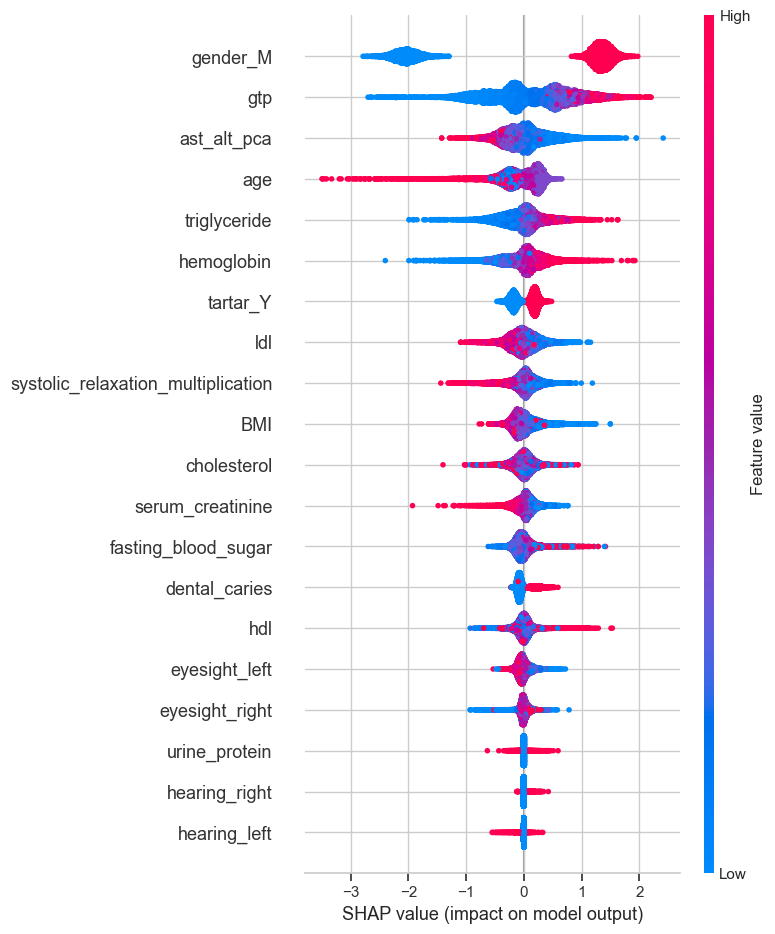

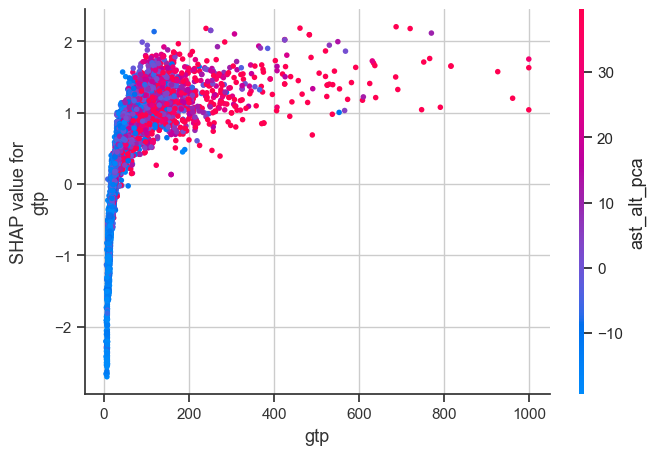

DimensionError: Length of features is not equal to the length of shap_values!

In [189]:

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)


plt.figure() 
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
plt.show()  


shap.dependence_plot('gtp', shap_values.values, X_test, feature_names=feature_names)
plt.show()  


shap.force_plot(explainer.expected_value, shap_values[0].values, X_test, feature_names=feature_names, matplotlib=True)
plt.show()  


plt.figure()
shap.plots.waterfall(shap_values[0])
plt.show()  

In [ ]:
shap.force_plot(explainer.expected_value, shap_values[0].values, X_test, feature_names=feature_names, matplotlib=True)
plt.show()  

ValueError: visualize() can only display Explanation objects (or arrays of them)!

In [ ]:
y_test.iloc[12]

np.int64(0)

In [ ]:
X_test.iloc[12]


age                                           50
eyesight_left                                1.5
eyesight_right                               1.2
hearing_left                                 1.0
hearing_right                                1.0
fasting_blood_sugar                         82.0
cholesterol                                183.0
triglyceride                                75.0
hdl                                         57.0
ldl                                        111.0
hemoglobin                                  11.8
urine_protein                                1.0
serum_creatinine                             0.9
gtp                                         14.0
dental_caries                                  0
gender_M                                   False
tartar_Y                                    True
systolic_relaxation_multiplication    48553024.0
BMI                                           21
ast_alt_pca                           -15.694037
Name: 11562, dtype: 

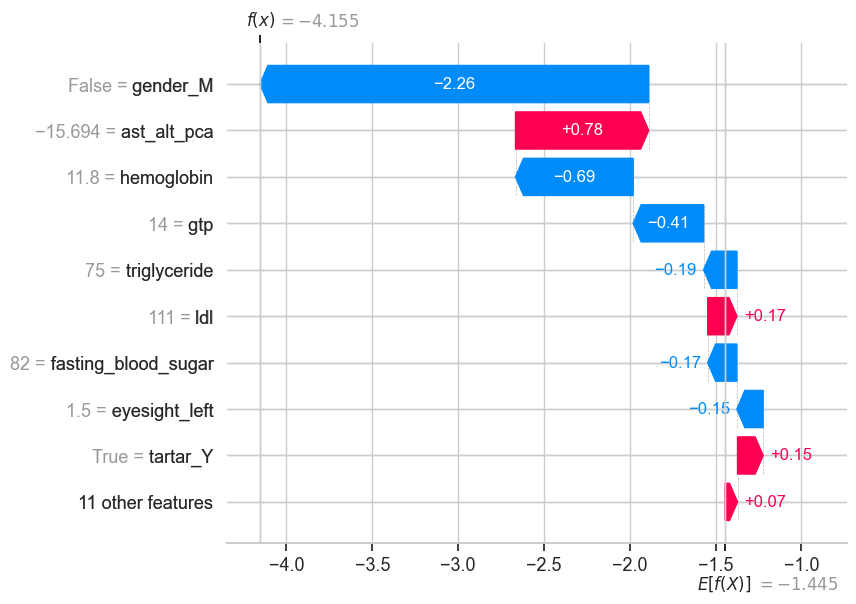

In [ ]:
shap.plots.waterfall(shap_values[12])